<a href="https://colab.research.google.com/github/deepan98raj-dotcom/git_notes_/blob/main/Session_36_R_CNN_and_YOLO_with_example_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 **The R-CNN Family:**

 The Two-Stage EraBefore YOLO, the standard approach was a two-stage detection process:

**Region Proposal:** The model identifies areas in the image that might contain an object.

  **Classification:** The model examines each proposed region to determine what it is and refines its boundary.
  
  **R-CNN (Regions with CNN features):** The pioneer. It used an external algorithm (Selective Search) to generate ~2,000 region proposals, which were then fed individually into a CNN. It was extremely slow (seconds per image) because it processed each proposal independently.


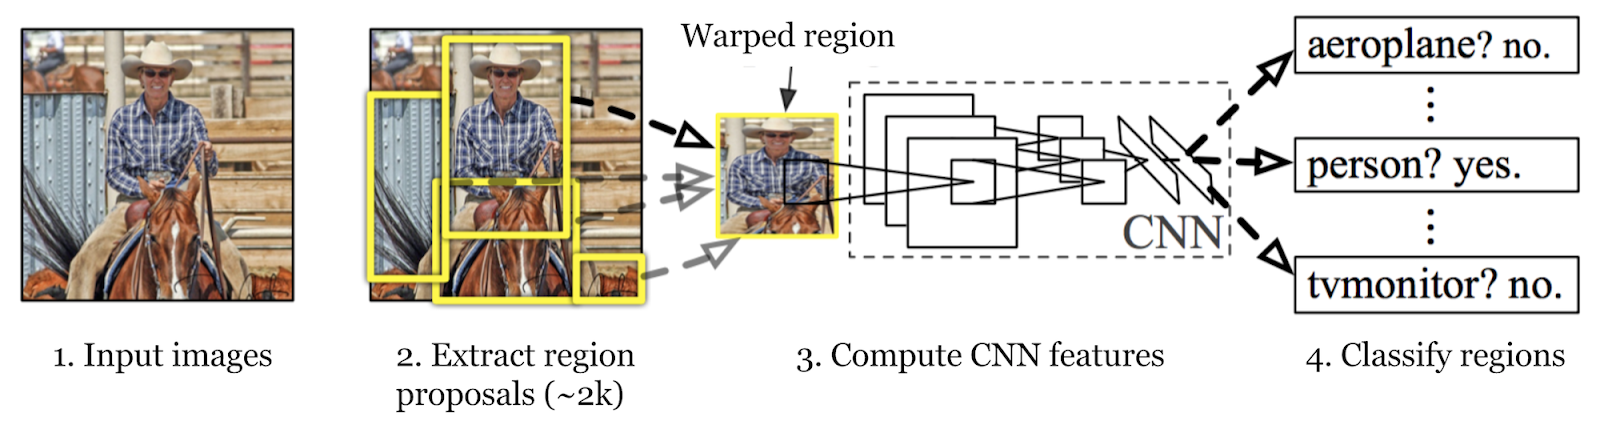


Following are thes steps involved in R-CNN

Let's say you have an image shown below.

The image is represented as **Height x Width x Depth** multidimensional arrays. Notation of width as w, height as h, depth as (x,y)

The input image is passed through Convolutional Neural Network. Final layer of the CNN returns the convolutional feature map.

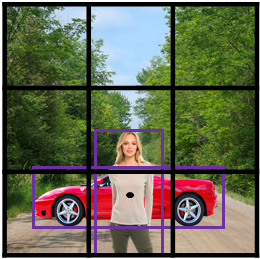

Generate anchor boxes
Anchor box is a box surrounding the objects (or called bounding box). We manually define the box and label its object class. This box has a certain height and width which is selected based on the heights and widths of objects in a training dataset.

Let's take two anchor boxes for demonstration purpose. Shape of Anchor Box 1 and box surrounding car is very much alike. Similarly shape of Anchor Box 2 and box around girl are similar.

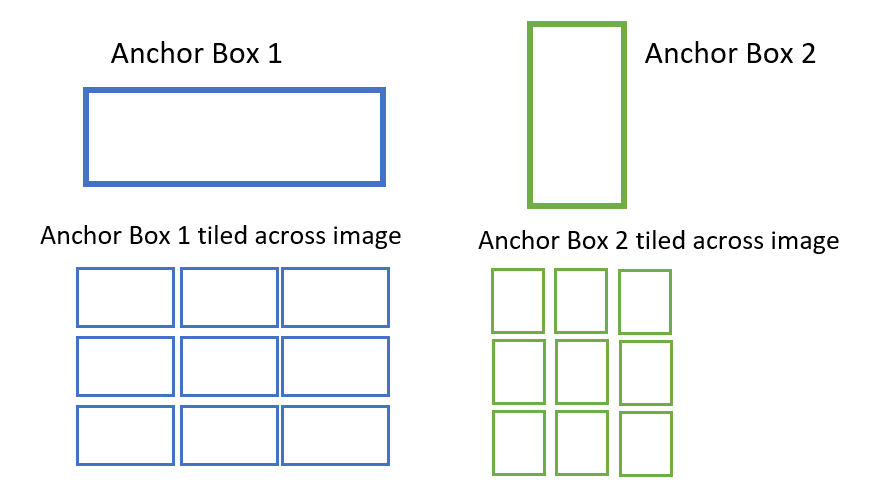

Remember we are making use of convolutional feature map as explained in the previous step. We will position anchor boxes for each position of the convolutional feature map to the input image. It returns tiled anchor boxes across the entire image (as shown above). Each anchor box produces prediction if it has our desired object or not. Prediction is in the form of binary classification. Let's say if the anchor box contains desired object it would be classified as "foreground" and rest would be background. Since we have two anchor boxes, we will have two predictions per position. Please make a note that some of the anchor boxes won't have our desired object as there are so many boxes.

**Classify anchor box as foreground/background**
To classify each anchor box, we use Intersection over Union (IOU) distance metric. It is used to describe the extent of overlap of anchor box with the desired object. The greater the region of overlap, the greater the IOU. If anchor box having IOU greater than 0.5, it will be considered foreground and those having less than 0.1 IOU are considered background.

**What is "desired" object?**

It is the target object which you want as output from the deep learning model. In deep learning it is called ground truth object.

**Bounding box regression adjustment**

In this step regression layer tries to make the coordinates of the bounding box around the desired object more precise. Coordinates of the object are width, height and depth (or called center).

Loss function of Regional Proposal Network is the sum of classification (cls) and regression (reg) loss. The classification loss is the entropy loss on whether it's a foreground or background. The regression loss is the difference between the regression of foreground box and that of ground truth box.





**Fast R-CNN:** Solved the redundancy by processing the entire image through the CNN first, then extracting features for the regions from the resulting feature map. This shared computation significantly boosted speed, but the region proposal process remained a bottleneck.  
  
  **Faster R-CNN:** Replaced the external "Selective Search" with a Region Proposal Network (RPN). The RPN is a small network that runs concurrently with the detection network, learning to propose regions itself. This made it much faster and established the state-of-the-art for accuracy for years.  

**The Evolution: Why YOLO?**

The R-CNN series focused on increasing precision, but the two-stage nature inherently limited speed. Even the "Fastest" R-CNN could not achieve the true real-time performance (30+ FPS) required for applications like autonomous driving or live video surveillance.  

YOLO (You Only Look Once) was developed by Joseph Redmon to fundamentally change the game. Instead of treating detection as two separate tasks, it treats it as a single regression problem.


| Feature | R-CNN / Faster R-CNN | YOLO |
| :--- | :--- | :--- |
| **Approach** | Two-stage (Propose → Classify) | Single-stage (Unified detection) |
| **Speed** | Moderate to Slow | Extremely Fast (Real-time) |
| **Context** | Looks at regions locally | Sees the entire image at once |
| **Accuracy** | Generally higher (especially for small objects) | High, but slightly lower on tiny objects |


---

### The Fundamental Philosophy of YOLO

Traditional methods (like R-CNN) inspect an image by first searching for objects (Region Proposals) and then classifying them. However, **YOLO processes the entire image in a single pass, predicting both what the object is and where it is located simultaneously.** This is why it is incredibly fast.

### Key Architectural Components of YOLO

YOLO's architecture generally consists of three main parts:

#### 1. Backbone

This is the feature extraction part of the network, typically using Convolutional Neural Networks (CNNs).

* **Function:** It extracts essential information such as shapes, colors, and edges from the image.
* **Usage:** While earlier versions used Darknet, modern versions utilize optimized networks like CSPDarknet.

#### 2. Neck

This section refines the features extracted by the backbone.

* **Function:** It helps in detecting objects of different sizes (multi-scale feature fusion). It integrates information across various stages to ensure both small and large objects are identified accurately.

Techniques like PANet (Path Aggregation Network) or FPN (Feature Pyramid Network) are used here to merge information, enabling the model to detect both tiny and massive objects simultaneously.

#### 3. Head

This is the final stage that produces the output.

* **Function:** It divides the image into a grid ($S \times S$) and for every grid cell, it predicts:
* **Class Probability:** What the object is.
* **Bounding Box coordinates:** Where the object is.
* **Confidence Score:** How certain the model is about the detection.



---

### How YOLO Works (The Process)

1. **Grid Division:** It divides the entire image into an $S \times S$ grid.
2. **Bounding Box Prediction:** Each grid cell proposes a specific number of boxes to determine if an object exists there.
3. **Confidence Score:** It calculates the probability that an object exists within those boxes.
4. **Non-Maximum Suppression (NMS):** If multiple boxes detect the same object, the algorithm keeps only the most accurate one and discards the rest.

---

### Why is YOLO preferred?

* **Real-time Speed:** It can process many frames per second (FPS), making it ideal for live video analysis.
* **Global Context:** By looking at the entire image at once, it understands the context of the objects better than region-based methods.
* **Low False Positives:** It is much less likely to mistake background elements for objects.

### Summary

YOLO is a sophisticated Deep Learning architecture that treats the image as a tensor and processes it as a whole to produce results rapidly rather than scanning every pixel individually. It is the backbone of technologies like self-driving cars, surveillance cameras, and medical imaging analysis.



In [ ]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 1.9 MB/s eta 0:00:00


In [ ]:
import cv2
from ultralytics import YOLO
from google.colab.patches import cv2_imshow # Especially for colab
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


**Initialize Model Singleton Pattern concept**

Helps Loading Model Globally

In [ ]:
class ObjectDetector:
    def __init__(self, model_name='yolov8n.pt'):
        # Nano model for speed
        self.model = YOLO(model_name)

    def detect(self, image_path, conf_threshold=0.5):
        # Clean inference
        results = self.model.predict(source=image_path, conf=conf_threshold, save=True)
        return results

# Initialize
detector = ObjectDetector()

**Execution Pipeline**

In [ ]:
def process_frame(image_path):
    # Detect objects
    results = detector.detect(image_path)

    # Extracting relevant data
    for result in results:
        boxes = result.boxes
        for box in boxes:
            cls = int(box.cls[0])
            conf = float(box.conf[0])
            print(f"Detected: {result.names[cls]} with confidence: {conf:.2f}")

# Test with a sample image
# Mention this path after uploading
process_frame('/content/car_girl cnn.webp')


image 1/1 /content/car_girl cnn.webp: 640x640 1 person, 1 car, 431.3ms
Speed: 17.7ms preprocess, 431.3ms inference, 45.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
Detected: person with confidence: 0.86
Detected: car with confidence: 0.63


In [ ]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 1.6 MB/s eta 0:00:00


In [ ]:
import cv2
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
import os

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


**Initialize Model Singleton Pattern Concept**

Helps Loading Model Gloabally

In [ ]:
class objectDetector:
  def __init__(self,model_name='yolov8n.pt'):
  # Nano model for speed
    self.model = YOLO(model_name)

  def detect(self, image_path, conf_threshold=0.5):
    # Clean inference
    results = self.model.predict(source=image_path, conf=conf_threshold, save=True)
    return results # Added return statement here

  #Initialize
detector = objectDetector()

In [ ]:
def process_frame(image_path):

  results = detector.detect(image_path)

  for result in results:
    boxes = result.boxes.cpu().numpy()
    for box in boxes:
      cls = int(box.cls[0])
      conf = float(box.conf[0])
      # Corrected result.name to result.names and f-string formatting for confidence
      print(f'Detected: {result.names[cls]} with Confidence: {conf:.2f}')

# Download a sample image for demonstration purposes
# The -nc flag ensures it only downloads if the file doesn't exist
!wget -nc https://ultralytics.com/images/zidane.jpg -O /content/zidane.jpg

# Call process_frame with the downloaded image
process_frame('/content/zidane.jpg')

File ‘/content/zidane.jpg’ already there; not retrieving.

image 1/1 /content/zidane.jpg: 384x640 2 persons, 138.0ms
Speed: 5.1ms preprocess, 138.0ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict-2
Detected: person with Confidence: 0.84
Detected: person with Confidence: 0.82
